In [4]:
#Library
import pandas as pd
import matplotlib.pyplot as plt
import spacy
from collections import Counter

In [5]:
df_train=pd.read_csv("data/train.csv")

In [6]:
df_train.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [7]:
df_train=df_train.drop(columns=['id'])

In [8]:
df_train.head(300)

,keyword,location,text,target
0,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...
295,apocalypse,NaN,Minecraft- NIGHT LUCKY BLOCK MOD (BOB APOCALYP...,0
296,apocalypse,NaN,Shot Through The Heart XV: You are going to to...,0
297,apocalypse,NaN,RT: Geek_Apocalypse: 4pm GMT :Hesse plays dark...,0
298,apocalypse,Las Vegas,I know where to go when the zombies take over!...,0


In [9]:
df_train.shape

(7613, 4)

In [10]:
print(df_train['target'].value_counts(normalize=True))

target
0    0.57034
1    0.42966
Name: proportion, dtype: float64


In [11]:
df_train["n_car"]=df_train['text'].str.len()
df_train["n_words"]=df_train['text'].str.split().str.len()

In [12]:
vides=df_train['text'].isna() | (df_train['text']=="")
print(vides.value_counts(normalize=True))

text
False    1.0
Name: proportion, dtype: float64


In [13]:
print("Voici le nombre de doublons dans le train",df_train.duplicated().sum())

Voici le nombre de doublons dans le train 52


Nombre de mots median :target
0    15.0
1    15.0
Name: n_words, dtype: float64


Nombre de mots median :target
0    101.0
1    115.0
Name: n_car, dtype: float64


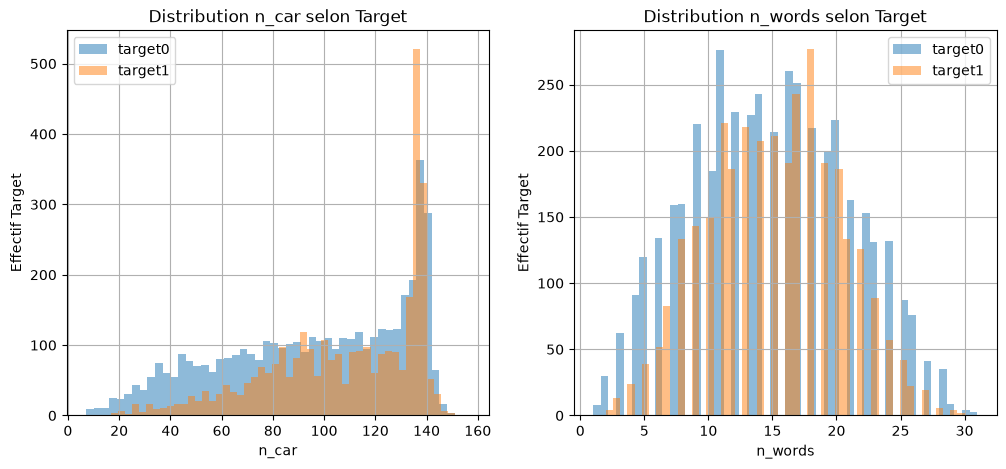

In [14]:
infos=["n_car","n_words"]
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for i,c in enumerate(infos):
    for cle,sous in df_train.groupby("target"):
        sous[c].hist(ax=ax[i],bins=50,alpha=0.5,label=f"target{cle}")
        ax[i].set_xlabel(c)
        ax[i].set_ylabel("Effectif Target")
        ax[i].legend()
        ax[i].set_title(f'Distribution {c} selon Target')

print(f"Nombre de mots median :{df_train.groupby("target")["n_words"].median()}")
print(f"Nombre de mots median :{df_train.groupby("target")["n_car"].median()}")

We see a very proportionate dataset

In [15]:
print(df_train["location"].nunique())

3341


In [16]:
top_n = 20 #on définit combien de villes on veut garder
top_locations = df_train["location"].value_counts().head(top_n).index #compte dans l'ordre décroissant les occurences de location et n'en extrait que les labels

df_train["location_grouped"] = df_train["location"].where(
    df_train["location"].isin(top_locations), "autre"
)

#is in test si la ville est dans le top locations
#df_train["location"].where(condition, "autre") si la condition est respecté, on garde l'élément, sinon on lui impute 'autre'
dummies = pd.get_dummies(df_train["location_grouped"], prefix="loc")

In [24]:
ponctuation = ["AM",".", "!", "?","#","FedEx","Journal","USATODAY","Accident","accident"]

for p in ponctuation:
    df_train[f"has_{p}"] = df_train["text"].str.contains(p, regex=False)
    
    prop_present = df_train["target"][df_train[f"has_{p}"] == True].value_counts(normalize=True)
    prop_absent = df_train["target"][df_train[f"has_{p}"] == False].value_counts(normalize=True)
    
    print(f"Proportion de target quand présence de {p} :")
    print(prop_present)
    print(f"Proportion de target quand absence de {p} :")
    print(prop_absent)
    print()

Proportion de target quand présence de AM :
target
0    0.603448
1    0.396552
Name: proportion, dtype: float64
Proportion de target quand absence de AM :
target
0    0.569828
1    0.430172
Name: proportion, dtype: float64

Proportion de target quand présence de . :
target
0    0.512504
1    0.487496
Name: proportion, dtype: float64
Proportion de target quand absence de . :
target
0    0.740052
1    0.259948
Name: proportion, dtype: float64

Proportion de target quand présence de ! :
target
0    0.727399
1    0.272601
Name: proportion, dtype: float64
Proportion de target quand absence de ! :
target
0    0.55396
1    0.44604
Name: proportion, dtype: float64

Proportion de target quand présence de ? :
target
0    0.71977
1    0.28023
Name: proportion, dtype: float64
Proportion de target quand absence de ? :
target
0    0.546644
1    0.453356
Name: proportion, dtype: float64

Proportion de target quand présence de # :
target
0    0.503123
1    0.496877
Name: proportion, dtype: float64
Pro

In [ ]:
df_train[["has_.", "has_!", "has_?"]].corr()

,has_.,has_!,has_?
has_.,1.000000,-0.068346,-0.188851
has_!,-0.068346,1.000000,0.021679
has_?,-0.188851,0.021679,1.000000


In [ ]:
df_train["has_url"] = df_train["text"].str.contains(r"https?://", regex=True)

prop_present = df_train["target"][df_train["has_url"] == True].value_counts(normalize=True)
prop_absent = df_train["target"][df_train["has_url"] == False].value_counts(normalize=True)
    
print("Proportion de target quand présence uniquement capital letters :")
print(prop_present)
print("Proportion de target quand absence de capital letters :")
print(prop_absent)
print()

Proportion de target quand présence uniquement capital letters :
target
1    0.546965
0    0.453035
Name: proportion, dtype: float64
Proportion de target quand absence de capital letters :
target
0    0.698243
1    0.301757
Name: proportion, dtype: float64



In [ ]:
df_train["url_is_https"] = df_train["text"].str.contains(r"https://", regex=True)
prop_present = df_train["target"][df_train["url_is_https"] == True].value_counts(normalize=True)
prop_absent = df_train["target"][df_train["url_is_https"] == False].value_counts(normalize=True)
    
print("Proportion de target quand présence uniquement capital letters :")
print(prop_present)
print("Proportion de target quand absence de capital letters :")
print(prop_absent)
print()

Proportion de target quand présence uniquement capital letters :
target
0    0.670762
1    0.329238
Name: proportion, dtype: float64
Proportion de target quand absence de capital letters :
target
0    0.564668
1    0.435332
Name: proportion, dtype: float64



In [ ]:
df_train["has_CAP"] = df_train["text"].str.isupper()

In [ ]:
prop_present = df_train["target"][df_train["has_CAP"] == True].value_counts(normalize=True)
prop_absent = df_train["target"][df_train["has_CAP"] == False].value_counts(normalize=True)
    
print("Proportion de target quand présence uniquement capital letters :")
print(prop_present)
print("Proportion de target quand absence de capital letters :")
print(prop_absent)
print()

Proportion de target quand présence uniquement capital letters :
target
0    0.74
1    0.26
Name: proportion, dtype: float64
Proportion de target quand absence de capital letters :
target
0    0.569219
1    0.430781
Name: proportion, dtype: float64



In [ ]:
import sys
!{sys.executable} -m spacy download en_core_web_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 62.5 MB/s  0:00:00m0:00:0100:01

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')


In [ ]:
nlp = spacy.load("en_core_web_md")

df_train["tokens"] = [
    [token.lemma_.lower() for token in doc if token.is_alpha and not token.is_stop]
    for doc in nlp.pipe(df_train["text"], batch_size=50)
]

#lemma_ : donne le lemme du token, sa forme canonique : ex : "running"->"run"
#lower(): met en minucule
#token.is_alpha : lettre alphabet ou non, donc le if token.is_alpha supprime la ponctuation
#token.is_stop : mots inutiles 'ex: déterminants', donc le 'and not token.is_stop' ne garde que les mots utiles
#  

In [ ]:
tokens=df_train["tokens"].explode()
freq=Counter(tokens)

In [ ]:
print(f"taille du vocabulaire:{len(freq)}")

taille du vocabulaire:11867


In [ ]:
print('Hapax',sum(c == 1 for w, c in freq.items()))

Hapax 6742


In [ ]:
print(freq.most_common(20))

[('like', 394), ('fire', 349), ('amp', 298), ('new', 227), ('go', 220), ('people', 198), ('news', 191), ('get', 189), ('year', 175), ('video', 174), ('kill', 168), ('burn', 165), ('crash', 161), ('emergency', 159), ('disaster', 158), ('come', 155), ('good', 154), ('body', 154), ('attack', 153), ('bomb', 149)]


In [ ]:
for cle, sous in df_train.groupby("target"):
    tokens_classe = sous["tokens"].explode()
    freq_classe = Counter(tokens_classe)
    print(f"--- target {cle} ---")
    print(freq_classe.most_common(15))
    print()

--- target 0 ---
[('like', 293), ('amp', 192), ('new', 170), ('go', 159), ('get', 140), ('body', 118), ('love', 117), ('good', 116), ('come', 105), ('day', 102), ('know', 102), ('video', 102), ('time', 97), ('think', 97), ('want', 96)]

--- target 1 ---
[('fire', 260), ('kill', 149), ('news', 134), ('disaster', 119), ('california', 115), ('crash', 112), ('suicide', 112), ('police', 109), ('year', 109), ('people', 106), ('amp', 106), ('attack', 104), ('family', 103), ('like', 101), ('bomb', 101)]



In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Comme tes tokens sont déjà nettoyés, on les rejoint en texte
df_train["texte_clean"] = df_train["tokens"].apply(" ".join)

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df_train["texte_clean"])

print(X.shape)  # (n_documents, taille_vocabulaire)
print(vectorizer.get_feature_names_out()[:20])  # les 20 premiers mots du vocabulaire

(7613, 11841)
['aa' 'aaaa' 'aaaaaaallll' 'aaaaaand' 'aaarrrgghhh' 'aan' 'aannnnd' 'aar'
 'aashiqui' 'ab' 'aba' 'abandon' 'abbandoned' 'abbott' 'abbruchsimulator'
 'abbswinston' 'abc' 'abcnews' 'abe' 'aberdeen']


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
df_train_split, df_val_split = train_test_split(
    df_train,
    test_size=0.2,
    random_state=0,
    stratify=df_train["target"]
)

In [ ]:
y_train = df_train_split["target"]
y_val = df_val_split["target"]

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(min_df=2,max_df=0.9,max_features=10000)
X_train_tfidf = tfidf.fit_transform(df_train_split["texte_clean"])
X_val_tfidf = tfidf.transform(df_val_split["texte_clean"])

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report

model=LogisticRegression(max_iter=2000)
model.fit(X_train_tfidf,y_train)

y_pred=model.predict(X_val_tfidf)

print("Accuracy Score is",accuracy_score(y_val,y_pred))
print(classification_report(y_val,y_pred))

Accuracy Score is 0.8154957321076822
              precision    recall  f1-score   support

           0       0.80      0.91      0.85       869
           1       0.85      0.69      0.76       654

    accuracy                           0.82      1523
   macro avg       0.82      0.80      0.81      1523
weighted avg       0.82      0.82      0.81      1523



In [ ]:
df_test=pd.read_csv("data/test.csv")

In [ ]:
# 1. TF-IDF sur tout df_train
tfidf = TfidfVectorizer(min_df=2, max_df=0.9, max_features=10000)
X_train_tfidf = tfidf.fit_transform(df_train["texte_clean"])

# 2. Features booléennes sur tout df_train
features_bool = ["has_url", "has_CAP", "has_!", "has_?","url_is_https","has_."]
X_train_num = df_train[features_bool].astype(int).values

# 4. Combinaison
from scipy.sparse import hstack
X_train_final = hstack([X_train_tfidf, X_train_num])

# 5. Entraînement sur TOUT df_train
y_train = df_train["target"]

model = LogisticRegression(max_iter=2000)
model.fit(X_train_final, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [ ]:
import re

# 1. Tokenisation / lemmatisation spaCy
df_test["tokens"] = [
    [token.lemma_.lower() for token in doc if token.is_alpha and not token.is_stop]
    for doc in nlp.pipe(df_test["text"], batch_size=50)
]
df_test["texte_clean"] = df_test["tokens"].apply(" ".join)

# 2. Features booléennes (ponctuation, URL, majuscules)
df_test["has_url"] = df_test["text"].str.contains(r"https?://", regex=True)
df_test["has_CAP"] = df_test["text"].str.isupper()
df_test["has_!"] = df_test["text"].str.contains("!", regex=False)
df_test["has_?"] = df_test["text"].str.contains("?", regex=False)
df_test["has_!!"] = df_test["text"].str.contains("!!", regex=False)
df_test["has_."] = df_test["text"].str.contains(".", regex=False)
df_test["url_is_https"] = df_test["text"].str.contains(r"https://", regex=True)

# 3. Location groupée (top_locations vient du TRAIN, déjà calculé)
df_test["location_grouped"] = df_test["location"].where(
    df_test["location"].isin(top_locations), "autre"
)

# 4. TF-IDF (tfidf déjà fit sur le train — transform seul ici)
X_test_tfidf = tfidf.transform(df_test["texte_clean"])

# 5. Features booléennes en array
features_bool = ["has_url", "has_CAP", "has_!", "has_?","url_is_https","has_."]
X_test_num = df_test[features_bool].astype(int).values

In [ ]:
# 7. Combinaison finale
X_test_final = hstack([X_test_tfidf, X_test_num])

# 8. Prédiction
y_test_pred = model.predict(X_test_final)

In [ ]:
submission=pd.DataFrame({
    "id":df_test["id"],
    "target":y_test_pred
})

submission.to_csv("submission_4.csv", index=False)